In [ ]:
from tqdm import tqdm
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import Gemma3ForCausalLM, AutoTokenizer, AutoModelForCausalLM
import torch.nn.functional as F
import os

/Users/dhingra.k/projects/personal/CoRAG-for-Faithfulness/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print("Loading Qwen2.5-3B model...")

device = "mps"
print(f"Using device: {device}")

model_name = "qwen/qwen2.5-7b-instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name, device_map=device, output_attentions=True, output_hidden_states=True
)

model.eval()


Loading Qwen2.5-3B model...
Using device: mps


The following generation flags are not valid and may be ignored: ['output_attentions', 'output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Loading checkpoint shards: 100%|██████████| 4/4 [00:07<00:00,  1.86s/it]


Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(152064, 3584)
    (layers): ModuleList(
      (0-27): 28 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=3584, out_features=3584, bias=True)
          (k_proj): Linear(in_features=3584, out_features=512, bias=True)
          (v_proj): Linear(in_features=3584, out_features=512, bias=True)
          (o_proj): Linear(in_features=3584, out_features=3584, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=3584, out_features=18944, bias=False)
          (up_proj): Linear(in_features=3584, out_features=18944, bias=False)
          (down_proj): Linear(in_features=18944, out_features=3584, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((3584,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((3584,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((3584,), eps=1e-06)
    (ro

### Utils

In [29]:

def apply_chat_template(messages, strategy=None):
    if strategy is None:
        return tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
    else:
        formatted_text = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=False
        )
        return (
            formatted_text
            + "<|im_start|>assistant\n"
            + "..... ..... ..... ..... ..... ..... ..... ..... ..... ..... ..... ..... ..... "
        )


def generate_with_logit_tracking(
    text,
    model,
    tokenizer,
    device,
    max_new_tokens=20,
    strategy=None,
):
    """
    Generate tokens and return all logits using model.generate().
    Stops at max_new_tokens or when EOS token is reached.
    """
    # Format input with chat template
    formatted_text = apply_chat_template(text, strategy=strategy)
    inputs = tokenizer(formatted_text, return_tensors="pt").to(device)

    # Generate with return_dict_in_generate to get logits
    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        return_dict_in_generate=True,
        output_scores=True,
        output_hidden_states=True,
        output_attentions=True,
        do_sample=False,  # Greedy decoding
        pad_token_id=tokenizer.eos_token_id,
    )
    return outputs


def return_prompts(formatted_question):

    return {
        "none": [
            {
                "role": "system",
                "content": "You are a helpful assistant that answers multiple-choice questions using only the given context. Respond in option label only.",
            },
            {"role": "user", "content": formatted_question},
        ],
        "full": [
            {
                "role": "system",
                "content": "You are a helpful assistant that answers multiple-choice questions using only the given context. Think out aloud step by step before answering",
            },
            {"role": "user", "content": formatted_question},
        ],
        "hidden": [
            {
                "role": "system",
                "content": "You are a helpful assistant. Write down 100 words on the impact technology has in reducing the concentration of kids, followed by answering the following question in one line only.",
            },
            {"role": "user", "content": formatted_question},
        ],
        "....": [
            {
                "role": "system",
                "content": "You are a helpful assistant that answers multiple-choice questions using only the given context. Answering in one line only.",
            },
            {"role": "user", "content": formatted_question},
        ],
    }



def get_state(e, strategy=None):
    output = generate_with_logit_tracking(e, model, tokenizer, device, strategy=strategy)
    return (
        output,
        torch.cat([torch.cat(e) for e in output.hidden_states], axis=1).detach().cpu(),
    )

### Data Loader

In [4]:
import pandas as pd

df = pd.read_csv("result.csv")
df["choices.label"] = df["choices.label"].apply(eval)
df["choices.text"] = df["choices.text"].apply(eval)


formatted_questions = [
    """Question: {question}
Options: 
{options}
    """.format(
        question=each_question["question"],
        options="\n".join(
            [
                f"{i}: {e}"
                for i, e in zip(
                    each_question["choices.label"], each_question["choices.text"]
                )
            ]
        ),
    )
    for each_question in df[~df["non_reasoning_match"]].iloc[:100].iloc
]



### Perturbation of inner layers (In works)

In [4]:
# import transformer_lens
import transformer_lens.utils as utils
from transformer_lens.hook_points import (
    HookPoint,
)  # Hooking utilities
from transformer_lens import HookedTransformer, FactoredMatrix


In [5]:
device = "mps"
print(f"Using device: {device}")

model_name = "qwen/qwen2.5-7b-instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name)

model = HookedTransformer.from_pretrained(model_name)

model.eval()

Using device: mps


`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 4/4 [00:28<00:00,  7.05s/it]


Loaded pretrained model qwen/qwen2.5-7b-instruct into HookedTransformer


HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint()
  (blocks): ModuleList(
    (0-27): 28 x TransformerBlock(
      (ln1): RMSNormPre(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (ln2): RMSNormPre(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (attn): GroupedQueryAttention(
        (hook_k): HookPoint()
        (hook_q): HookPoint()
        (hook_v): HookPoint()
        (hook_z): HookPoint()
        (hook_attn_scores): HookPoint()
        (hook_pattern): HookPoint()
        (hook_result): HookPoint()
        (hook_rot_k): HookPoint()
        (hook_rot_q): HookPoint()
      )
      (mlp): GatedMLP(
        (hook_pre): HookPoint()
        (hook_pre_linear): HookPoint()
        (hook_post): HookPoint()
      )
      (hook_attn_in): HookPoint()
      (hook_q_input): HookPoint()
      (hook_k_input): HookPoint()
      (hook_v_input): HookPoint()
      (hook_mlp_in): HookPoint()
      (hook_att

In [6]:
torch.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [23]:
prompt_tokens = return_prompts(formatted_questions[0])
prompt_tokens_str = {k: tokenizer.apply_chat_template(v, tokenize=False, add_generation_prompt=True) for k, v in prompt_tokens.items()}

In [25]:
layer_to_ablate = 6
head_index_to_ablate = -3
k = [0]

def head_ablation_hook(value, hook: HookPoint):
    if k[0] > 15:
        value[:, :, head_index_to_ablate, :] = 0.0
    k[0] += 1
    return value

In [26]:
model.reset_hooks()
model.add_hook(utils.get_act_name("z", layer_to_ablate), head_ablation_hook)

In [28]:
generated_text = model.generate(
    prompt_tokens_str["hidden"],
    max_new_tokens=256,
    # other generation parameters
)

 28%|██▊       | 71/256 [04:58<12:57,  4.20s/it]   


In [31]:
print(generated_text)

system
You are a helpful assistant. Write down 100 words on the impact technology has in reducing the concentration of kids, followed by answering the following question in one line only.
user
Question: What do people typically do while playing guitar?
Options: 
A: cry
B: hear sounds
C: singing
D: arthritis
E: making music
    
assistant
Technology has transformed how kids engage by providing them with digital gadgets and interactive learning apps that often require minimal physical activity, leading to less concentration on traditional tasks. It's crucial to balance tech use to maintain kids' focus and mental engagement. People typically sing while playing the guitar, which is both a common and enjoyable way to enhance their musical experience and expression.


## Attention Analysis

- Decode State (Hidden and Full reasoning Strategy as the non relevant (or context) tokens are output)
- restart the kernel and run all cells above again (until the Perturbation Block)

In [ ]:
from tqdm import tqdm

strategy = "hidden"
attention_scores = []
for formatted_question in tqdm(formatted_questions):
    prompts = return_prompts(formatted_question)
    prompts = {strategy: prompts[strategy]}
    prompt_states = {key: get_state(value, strategy=strategy) for key, value in prompts.items()}

    input_length = prompt_states[strategy][0]["attentions"][0][0].shape[-1]
    data = []
    for each_token in range(min(len(prompt_states[strategy][0].attentions) - 2, 10)):
        question_attention = torch.cat(
            prompt_states[strategy][0]["attentions"][each_token + 1]
        )[:, :, :, 30:input_length]
        data.append(question_attention[:, :, :, :])
    attention_scores.append(torch.sum(torch.cat(data, axis=2), axis=-1).cpu())


100%|██████████| 100/100 [02:39<00:00,  1.60s/it]


In [6]:
mean_Scores = torch.mean(torch.stack(attention_scores), axis=0)

Text(0.5, 1.0, 'Mean Attention Score to Question Tokens')

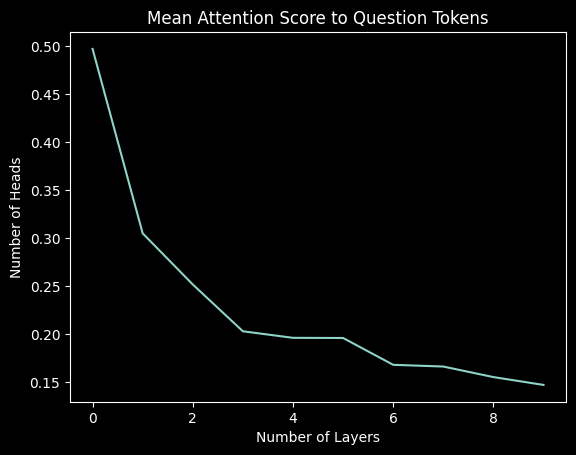

In [ ]:
plt.plot(np.mean(mean_Scores.cpu().numpy(), axis=(1, 0)))
plt.xlabel("Number of Layers")
plt.ylabel("Attention Score")
plt.title("Mean Attention Score to Question Tokens")

Text(0.5, 1.0, 'Mean Attention Score to Question Tokens')

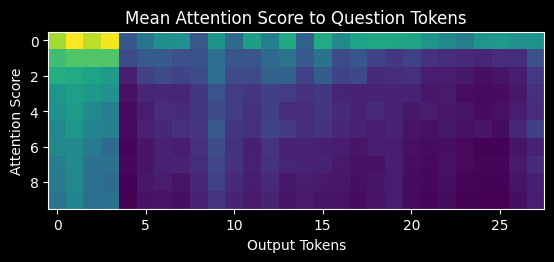

In [13]:
plt.imshow(np.mean(mean_Scores.cpu().numpy(), axis=(1)).T)
plt.xlabel("Output Tokens")
plt.ylabel("Attention Score")
plt.title("Mean Attention Score to Question Tokens")

In [14]:
### Filler token Attentions

In [39]:
from tqdm import tqdm

strategy = "...."
attention_scores = []
for formatted_question in tqdm(formatted_questions):
    prompts = return_prompts(formatted_question)
    prompts = {strategy: prompts[strategy]}
    prompt_states = {key: get_state(value, strategy=strategy) for key, value in prompts.items()}
    input_length = prompt_states[strategy][0]["attentions"][0][0].shape[-1]
    data = []
    data = torch.cat(prompt_states[strategy][0]["attentions"][0])[:, :, -10:, 30:input_length-20]
    attention_scores.append(torch.sum(data, axis=-1).cpu())

100%|██████████| 100/100 [00:45<00:00,  2.19it/s]


In [42]:
mean_Scores = torch.mean(torch.stack(attention_scores), axis=0)

Text(0.5, 1.0, 'Mean Attention Score to Question Tokens')

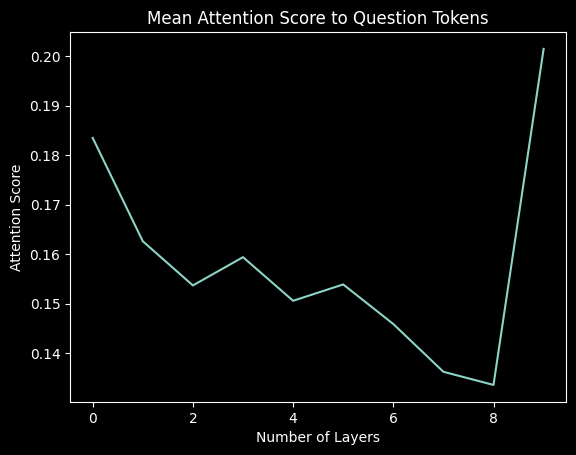

In [43]:
plt.plot(np.mean(mean_Scores.cpu().numpy(), axis=(1, 0)))
plt.xlabel("Number of Layers")
plt.ylabel("Attention Score")
plt.title("Mean Attention Score to Question Tokens")

Text(0.5, 1.0, 'Mean Attention Score to Question Tokens')

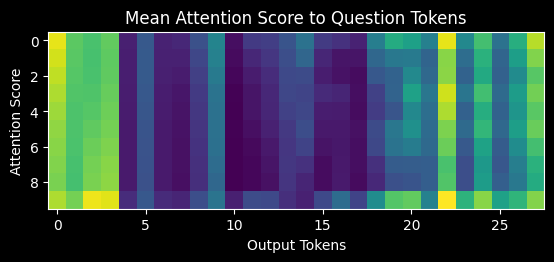

In [44]:
plt.imshow(np.mean(mean_Scores.cpu().numpy(), axis=(1)).T)
plt.xlabel("Output Tokens")
plt.ylabel("Attention Score")
plt.title("Mean Attention Score to Question Tokens")